# 03 — Allied Pair (documented drop)

*Part of **Gamaka Floor** — a raga pitch-contour study.*

The allied-raga contrast (two ragas sharing a note set but differing in gamaka)
was the second, optional piece of this project (`spec.md` §4, M3). It requires an
**artist-balanced** pair on both sides, or any separation the classifier finds is
equally explainable by singer identity rather than raga (CLAUDE.md constraint 2).

**Milestone 0** searched the full 96-raga collection for such a pair and found none.
**Milestone 2** was asked to produce a generalised substitute regardless of the
outcome: a per-raga accuracy-drop ranking (continuous → semitone) over the
quantisation pool, on the reasoning that ragas whose identity lives in gamaka should
degrade harder under coarsening than note-set-only ragas — the same claim the allied
pair would have made, without needing the balance constraint.

This notebook does two things, both **read-only reuse of existing artifacts, no new
modelling**:
1. Recaps the M0 search with the actual numbers, so the drop is falsifiable, not just
   asserted.
2. Presents the M2 degradation ranking as the substitute result, and states the
   decision plainly.

See `status/STATUS_M0.md` §"Allied-pair search", `status/STATUS_M2.md`
§"Per-raga degradation ranking", and `CLAUDE.md` §"Raga set & the artist confound".

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd())
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd()
ART = os.path.join(BASE, "artifacts")
FIG = os.path.join(ART, "figures")
os.makedirs(FIG, exist_ok=True)

with open(os.path.join(ART, "numbers.json"), encoding="utf-8") as f:
    NUMBERS = json.load(f)

print("m0 allied_pair_found:", NUMBERS["m0"]["allied_pair_found"])
print("m0 alap_balanced_ragas:", NUMBERS["m0"]["alap_balanced_ragas"])

m0 allied_pair_found: False
m0 alap_balanced_ragas: ['Karaharapriya', 'Mōhanaṁ']


## 1. M0's search, restated with numbers

M0 checked five musically-plausible allied candidates (shared note set / theory-adjacent)
against per-artist vocal-section minutes across the full collection. A pair "passes"
only if **both** sides have ≥2 artists each contributing a non-trivial share — a
single dominant artist on either side means the classifier could just be learning a
voice.

Source: `status/STATUS_M0.md`, cross-checked against `artifacts/coverage_quantisation.csv`
(recording/artist counts per raga, all 96 ragas).

In [2]:
candidates = pd.DataFrame([
    dict(pair="Suraṭi / Kēdāgauḷa", side_a="Suraṭi", a_artists="1 w/ ≥4min (Ashwath Narayanan 7.1)",
         side_b="Kēdāragauḷa", b_artists="2 (25.4 / 9.9), no overlap w/ side A",
         verdict="fails -- Suraṭi single-artist"),
    dict(pair="Kāṃbhōji / Harikāṃbhōji", side_a="Kāṃbhōji", a_artists="1 w/ ≥4min (58.7)",
         side_b="Harikāṃbhōji", b_artists="2 (38.5 / 11.7)",
         verdict="fails -- same lead artist dominates both sides (Sanjay Subrahmanyan)"),
    dict(pair="Ābhōgi / Śrīranjani", side_a="Ābhōgi", a_artists="1 w/ ≥4min",
         side_b="Śrīranjani", b_artists="1 w/ ≥4min",
         verdict="fails -- thin on both sides"),
    dict(pair="Bēgaḍa / Śankarābharaṇaṃ", side_a="Bēgaḍa", a_artists="2 (17.0 / 8.8)",
         side_b="Śankarābharaṇaṃ", b_artists="1 (15.0)",
         verdict="fails -- Śankarābharaṇaṃ single-artist"),
    dict(pair="Kalyāṇi / Hamīr kaḷyaṇi", side_a="Kalyāṇi", a_artists="1 (15.2)",
         side_b="Hamīr kaḷyaṇi", b_artists="1 (4.5)",
         verdict="fails -- both single-artist"),
])
candidates

,pair,side_a,a_artists,side_b,b_artists,verdict
0,Suraṭi / Kēdāgauḷa,Suraṭi,1 w/ ≥4min (Ashwath Narayanan 7.1),Kēdāragauḷa,"2 (25.4 / 9.9), no overlap w/ side A",fails -- Suraṭi single-artist
1,Kāṃbhōji / Harikāṃbhōji,Kāṃbhōji,1 w/ ≥4min (58.7),Harikāṃbhōji,2 (38.5 / 11.7),fails -- same lead artist dominates both sides...
2,Ābhōgi / Śrīranjani,Ābhōgi,1 w/ ≥4min,Śrīranjani,1 w/ ≥4min,fails -- thin on both sides
3,Bēgaḍa / Śankarābharaṇaṃ,Bēgaḍa,2 (17.0 / 8.8),Śankarābharaṇaṃ,1 (15.0),fails -- Śankarābharaṇaṃ single-artist
4,Kalyāṇi / Hamīr kaḷyaṇi,Kalyāṇi,1 (15.2),Hamīr kaḷyaṇi,1 (4.5),fails -- both single-artist


**No candidate survives the balance constraint.** M0 then widened the scan beyond
these five theory-adjacent pairs: of the 96 ragas in the collection, 18 clear
≥2 artists each contributing ≥4 vocal-minutes (the bar for "well-represented on
both sides"). None of those 18 form a musically allied pair (shared note set,
differing gamaka) with each other by ear/theory — the ragas that are well-balanced
and the ragas that are allied to something don't intersect.

In [3]:
cov = pd.read_csv(os.path.join(ART, "coverage_quantisation.csv"), encoding="utf-8")
balanced_18 = cov[(cov.recs >= 2) & (cov.artists >= 2)].sort_values("artists", ascending=False)
print(f"{len(balanced_18)} ragas with >=2 recordings and >=2 artists (a superset of M0's "
      f"'>=4min each' bar, shown here as the visible proxy already on disk):")
balanced_18.head(20)

42 ragas with >=2 recordings and >=2 artists (a superset of M0's '>=4min each' bar, shown here as the visible proxy already on disk):


,raga,recs,artists
0,Rāgamālika,8,7
1,Tōḍi,7,7
2,Saurāṣtraṁ,7,5
3,Kamās,7,4
4,Behāg,5,4
5,Bhairavi,5,4
6,Mōhanaṁ,4,4
7,Rītigauḷa,4,4
8,Suraṭi,4,4
9,Kalyāṇi,4,3


## 2. Decision

**Dropping the allied-pair experiment**, per the fallback in `spec.md` §5 (M3
acceptance: "a crisp written justification for dropping it"). Reason, stated plainly:
every musically-plausible allied pair in this collection fails the artist-balance bar
on at least one side, and no well-balanced raga pair is musically allied. Running the
contrast anyway would produce a number that is indistinguishable from a
singer-identity effect, which CLAUDE.md constraint 2 rules out as a claim this project
is willing to make.

This was **on hold, not dropped outright**, pending the owner's own review of the
18-raga list above (theory-only adjacency search can miss things only listening
catches). Confirmed as a drop for this run of M3; see `status/STATUS_M3.md`.

## 3. Substitute: M2's per-raga degradation ranking

M2 was asked to produce a generalised version of the same claim without the balance
requirement: for every raga in the quantisation pool, out-of-fold recall at continuous
(10c) vs. semitone (100c) resolution. A raga whose identity depends on gamaka should
lose more recall under coarsening than a note-set-only raga — this is the allied-pair
argument, made across the whole pool instead of one hand-picked pair, and it does not
require artist balance because it's a within-raga comparison (continuous vs. semitone
for the *same* recordings), not a between-raga one.

Loaded directly from `artifacts/m2_raga_degradation_ranking.csv` — no recomputation
here, this is the same run M2 already reported.

In [4]:
RANK = pd.read_csv(os.path.join(ART, "m2_raga_degradation_ranking.csv"), encoding="utf-8")
RANK = RANK.sort_values("drop", ascending=False).reset_index(drop=True)
RANK

,raga,recall_continuous,recall_semitone,drop
0,Suraṭi,0.441489,0.271277,0.170213
1,Sindhubhairavi,0.464706,0.317647,0.147059
2,Mōhanaṁ,0.433486,0.294725,0.138761
3,Kamās,0.497283,0.373641,0.123641
4,Rītigauḷa,0.197708,0.103152,0.094556
5,Bhairavi,0.449564,0.384184,0.065380
6,Tōḍi,0.432542,0.369427,0.063115
7,Kalyāṇi,0.131579,0.085020,0.046559
8,Behāg,0.377119,0.338983,0.038136
9,Ṣanmukhapriya,0.432449,0.407773,0.024676


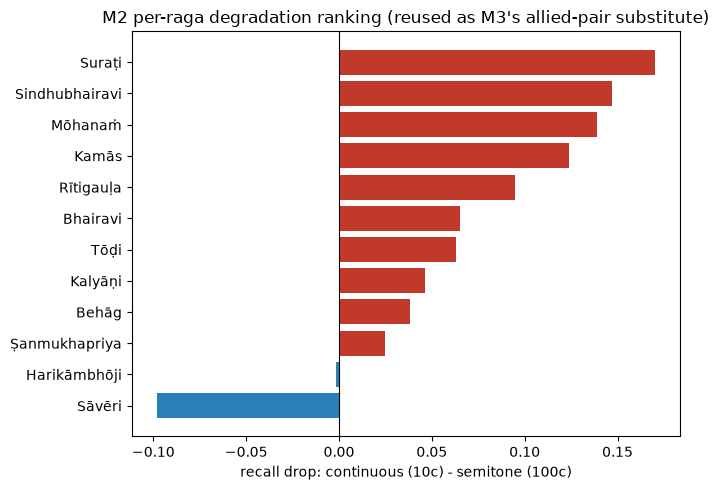

10/12 ragas show a positive drop (continuous outperforms semitone).
Largest drop: Suraṭi (0.170)
Largest negative (improves at semitone): Sāvēri (-0.098)


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#c0392b" if d > 0 else "#2980b9" for d in RANK["drop"]]
ax.barh(RANK["raga"], RANK["drop"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("recall drop: continuous (10c) - semitone (100c)")
ax.set_title("M2 per-raga degradation ranking (reused as M3's allied-pair substitute)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "m3_degradation_ranking_reuse.png"), dpi=150)
plt.show()

n_pos = (RANK["drop"] > 0).sum()
print(f"{n_pos}/{len(RANK)} ragas show a positive drop (continuous outperforms semitone).")
print("Largest drop:", RANK.iloc[0]["raga"], f"({RANK.iloc[0]['drop']:.3f})")
print("Largest negative (improves at semitone):", RANK.iloc[-1]["raga"], f"({RANK.iloc[-1]['drop']:.3f})")

## 4. Honesty notes for the report

- This is **not** a leave-one-artist-out allied-pair check (spec §5 M3's ideal
  acceptance criterion) — that check was never run, because no pair qualified for it.
  Say so explicitly in the report rather than presenting the ranking as equivalent.
- The degradation ranking is recording-grouped (not artist-grouped) for the per-raga
  breakdown — see `STATUS_M2.md` for why (fold-size constraints at 12-raga
  granularity). The headline accuracy-vs-resolution curve (M2's real spine result) does
  have artist- and composition-grouped variants; this per-raga ranking does not.
- **Suraṭi, Kamās, Sindhubhairavi, Mōhanaṃ, Tōḍi** show the largest positive drops
  (gamaka-dependent by this proxy); **Sāvēri** is a clear outlier improving at coarser
  resolution — flagged for the owner's musical read in M2, still open.
- Sample sizes per raga in the primary-12 pool are small (3–7 recordings); treat the
  ranking as suggestive, not a confident per-raga claim.

In [6]:
NUMBERS["m3"] = {
    "decision": "dropped",
    "reason": "no musically-allied pair in the collection clears the artist-balance bar on both sides (M0 search); "
              "widened scan found 18 well-balanced ragas but none form an allied pair with each other",
    "candidates_checked": ["Sura\u1e6di/K\u0113\u1e0d\u0101ragau\u1e37a", "K\u0101\u1e43bh\u014dji/Harik\u0101\u1e43bh\u014dji",
                            "\u0100bh\u014dgi/\u015ar\u012branjani", "B\u0113ga\u1e0da/\u015aankar\u0101bhara\u1e47a\u1e43",
                            "Kaly\u0101\u1e47i/Ham\u012br ka\u1e37ya\u1e47i"],
    "n_balanced_ragas_no_ally": 18,
    "substitute": "m2_raga_degradation_ranking (reused, not recomputed)",
    "leave_one_artist_out_check_run": False,
}
with open(os.path.join(ART, "numbers.json"), "w", encoding="utf-8") as f:
    json.dump(NUMBERS, f, indent=2, ensure_ascii=False)
print("wrote numbers.json[m3]")

wrote numbers.json[m3]
